In [64]:
from datasets import load_dataset, get_dataset_config_names


config_name = "sentence-pair-task1"
dataset = load_dataset("JonathanZha/PADBen", config_name)

for key, value in dataset["train"][:2].items():
    print(key, value)

configs = get_dataset_config_names("JonathanZha/PADBen")
print(f"Available configurations ({len(configs)}):")
for name in configs:
    print(f"  - {name}")

idx [0, 1]
sentence_pair [['Souray married former WWE professional wrestler Barbara Blank , better known as Kelly Kelly in February 2016 . They have separated in October 2017 .', 'Souray wed former WWE professional wrestler Barbara Blank (aka Kelly Kelly) in February 2016, but they separated in October 2017.'], ["Moffitt stated that before individuals are tested for the gene's long or short forms, these findings must be confirmed in a new study.", 'Professor Moffitt said the results needed to be replicated before pursuing testing of individuals for the presence of the long or short versions of the gene .']]
label_pair [[0, 1], [1, 0]]
Available configurations (25):
  - sentence-pair-task1
  - sentence-pair-task2
  - sentence-pair-task3
  - sentence-pair-task4
  - sentence-pair-task5
  - exhaustive-task1
  - exhaustive-task2
  - exhaustive-task3
  - exhaustive-task4
  - exhaustive-task5
  - sampling-30-70-task1
  - sampling-30-70-task2
  - sampling-30-70-task3
  - sampling-30-70-task4
 

In [75]:
import pandas as pd


df = pd.DataFrame(dataset["train"][:20000])
df['first_sentence'] = df['sentence_pair'].apply(lambda x: x[0])
df['second_sentence'] = df['sentence_pair'].apply(lambda x: x[1])
df['label_first'] = df['label_pair'].apply(lambda x: x[0])
df['label_seconod'] = df['label_pair'].apply(lambda x: x[1])
df.drop(['sentence_pair', 'label_pair'], axis=1, inplace=True)

In [42]:
%load_ext autoreload
%autoreload 2

import os
os.sys.path.append('../scripts/')
    
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx
import scipy.stats as ss
import pandas as pd
import numpy as np

from IPython.display import HTML, display_html
from phd_qwen_CUDA_clean import get_phd, load_roberta_model, load_qwen_model, get_embeds, preprocess_text
from lexicalrichness import LexicalRichness
from collections import Counter, defaultdict
from tqdm import tqdm
from phd_scale import set_all_seeds, load_qwen_model, get_embeds, get_answer,\
                      get_stats, get_embeds_tsne, get_mst_edge_lengths, calculate_df_edges, visualize_text
from phd_qwen_CUDA_clean import preprocess_text, pairwise_distances


set_all_seeds(42)
sns.set_style("darkgrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:

# df_en = pd.read_json("../PHD_experiments/notebooks/PHD_another/data/dev_intrinc_dimensions_roberta_gemma_qwen_phd__mle_twonn_tle.json")
tokenizer, model = load_qwen_model("google/gemma-4-E4B-it", device='cuda:3', token=token)
# df_en['gemini_tokenizer_len'] = df_en['text'].apply(lambda x: get_len_tokens(tokenizer, preprocess_text(x)))
# text = df_en['text'].values.tolist()[1]
# texts = df_en['text'].values.tolist()
# models = ['human', 'llama3-70b', 'gpt4o', 'gpt4']
# df_en = df_en.query("model in @models")
# df_en = df_en.query("gemini_tokenizer_len < 1024")

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Модель загружена на: cuda:3


In [76]:
df1 = df[['idx', 'first_sentence', 'label_first']].rename(columns={'first_sentence': 'sentence', 'label_first': 'label'}).assign(order='first')
df2 = df[['idx', 'second_sentence', 'label_seconod']].rename(columns={'second_sentence': 'sentence', 'label_seconod': 'label'}).assign(order='second')
df_concat = pd.concat([df1, df2])
df_concat = df_concat.rename(columns={'sentence': 'text'})
df_en = df_concat

In [ ]:
from tqdm import tqdm
from phd_scale import PHDimScale, get_embeds, plot_median_by_param_value


d_hat_stats_df_list = []
d_energy_range_stats_df_list = []
d_energy_upper_stats_df_list = []
d_energy_lower_stats_df_list = []
d_hat_stats_df_noise_list = []
d_energy_stats_df_noise_list = []
env_mean_by_n_list = []
texts = df_en['text'].values.tolist()
indices = df_en.index.tolist()
dfs_list = []
for index_num, (text, index) in enumerate(tqdm(zip(texts, indices))):
    # text stats calculation
    embeds, tokens = get_embeds(text, tokenizer, model, returns_tokenized=True)
    phd_dim_scale = PHDimScale(n_fraction_list=[0.6, 0.7, 0.8, 0.9], p_range=0.5, replace=False)
    d_hat_stats_df, d_energy_range_stats_df, d_energy_upper_stats_df, d_energy_lower_stats_df = phd_dim_scale.calculate(
        embeds,
        index,
        tokens
    )
    dfs_list.append(phd_dim_scale.dfs)
    d_hat_stats_df_list.append(d_hat_stats_df)
    d_energy_range_stats_df_list.append(d_energy_range_stats_df)
    d_energy_upper_stats_df_list.append(d_energy_upper_stats_df)
    d_energy_lower_stats_df_list.append(d_energy_lower_stats_df)
    env_mean_by_n_list.append(phd_dim_scale.env_mean_by_n)

    if (index_num - 1) % 100 == 0:
        import pickle
        with open(f"../data/padben_{config_name}.pickle", 'wb') as fd:
            pickle.dump([
                df_en,
                d_hat_stats_df_list,
                d_energy_range_stats_df_list,
                d_energy_upper_stats_df_list,
                d_energy_lower_stats_df_list,
                dfs_list
            ], fd)


106it [00:43,  2.56it/s]

In [71]:
df_en

,idx,text,label,order
0,0,Souray married former WWE professional wrestle...,0,first
1,1,Moffitt stated that before individuals are tes...,1,first
2,2,Produced by Oscar Hammerstein II the show was ...,0,first
3,3,Three vigilante assaults compelled the hacker ...,1,first
4,4,Safa Masjid or Safa Shahouri masjid is located...,0,first
...,...,...,...,...
95,95,"On April 25, 2016, Jamar Howard was swapped fo...",1,second
96,96,"According to Mr. Mask, Mr. Cullen is scheduled...",1,second
97,97,""" Qualcomm has enjoyed many years of selling C...",0,second
98,98,It aimed to raise the $90 million McGreevey an...,1,second


In [73]:
!mkdir ../data/figures

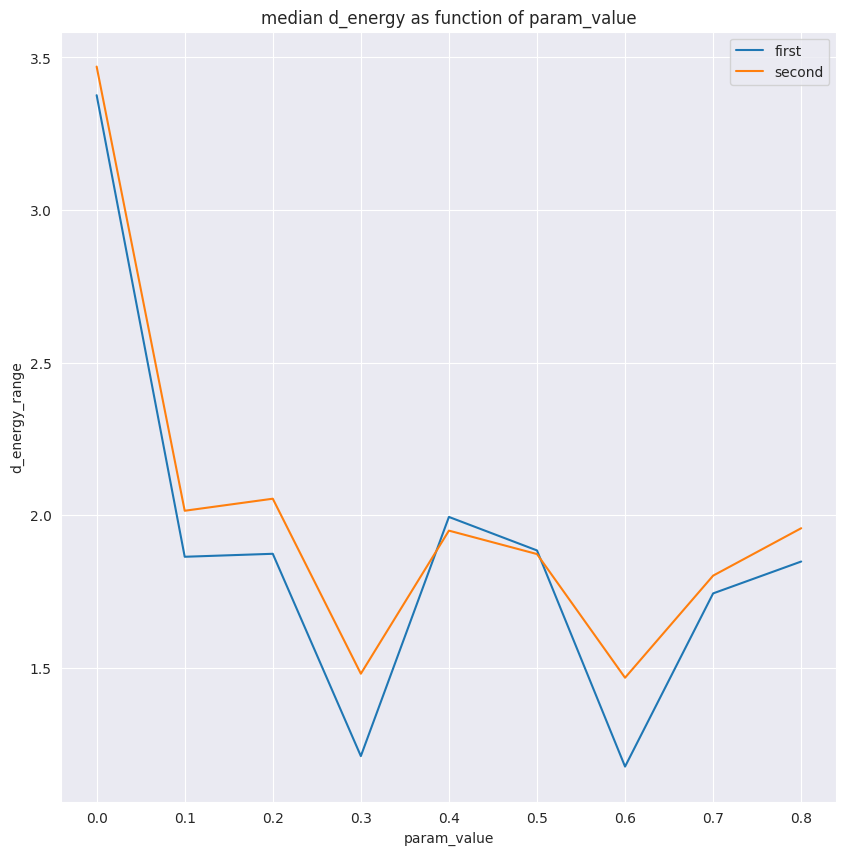

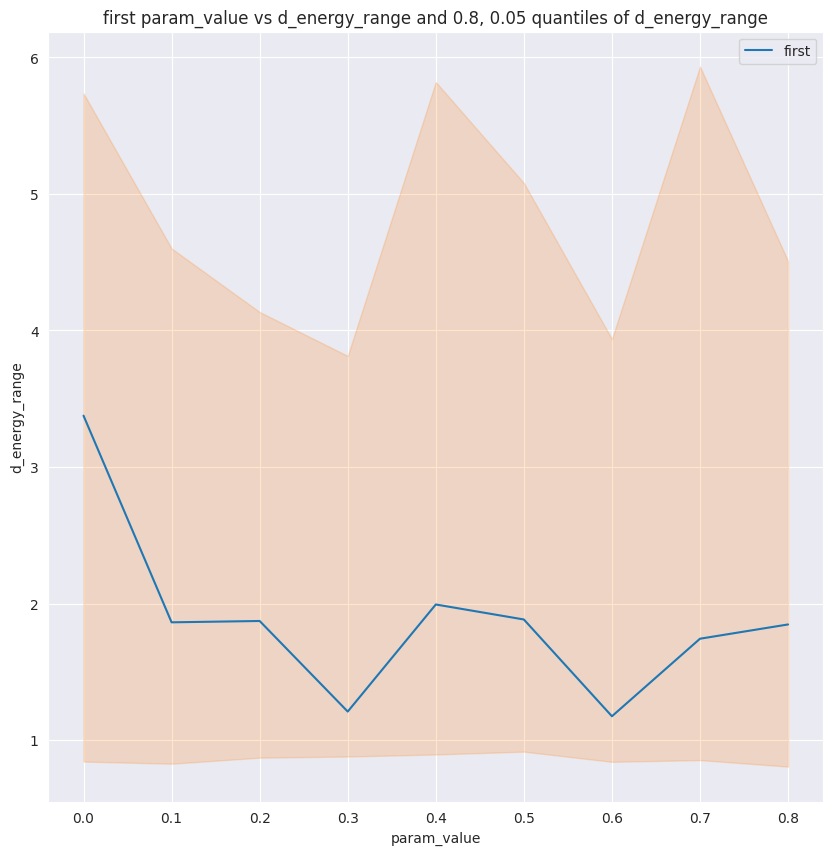

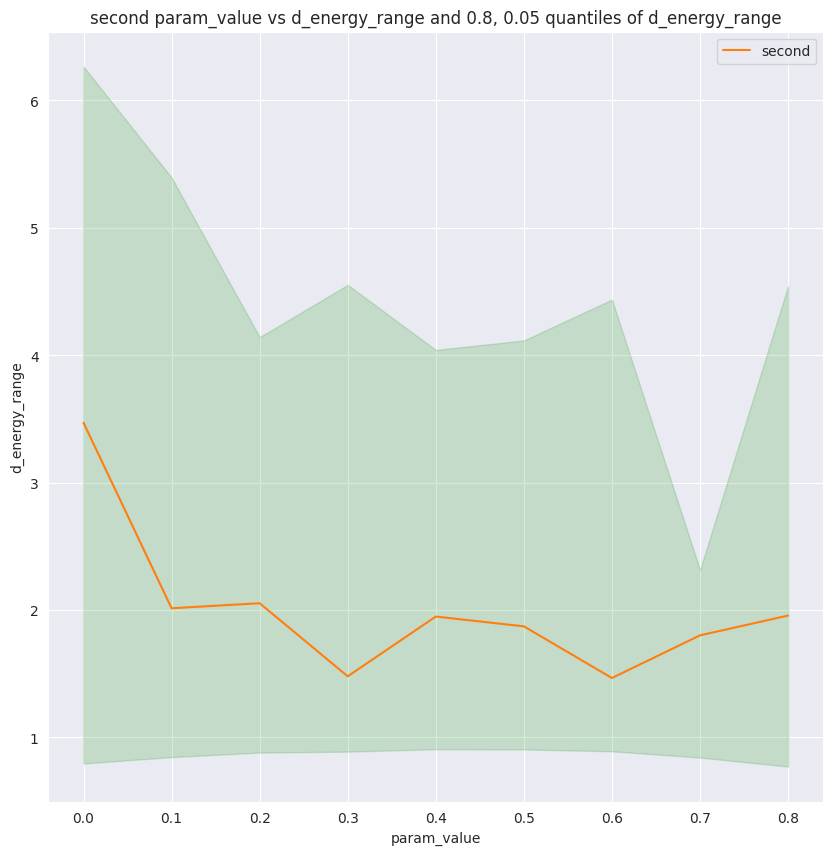

<Figure size 640x480 with 0 Axes>

In [74]:
# number_of_texts = 45000
number_of_texts = df_en.shape[0]
plot_median_by_param_value(
    df_en.rename(columns={'order': 'model'}),
    d_energy_range_stats_df_list,
    limit=number_of_texts,
    min_count_plot=number_of_texts * 0.032,
    obj_name='d_energy_range', 
    xlim=0.9,
    filename_save='../data/figures/d_energy_range'
)